# Week 5 · Day 1 — Making Data Visible: Matplotlib & Seaborn

Everything we computed last week was a **number** — a mean, a standard deviation, a correlation. Numbers are precise, but the human eye finds patterns in a *picture* that it would never spot in a table of figures.

Today those numbers become pictures. This is also where the statistics from last week finally become visible:
- a **histogram** shows a distribution,
- a **boxplot** shows the quartiles,
- a **scatter plot** shows a correlation,
- a **heatmap** shows the whole correlation matrix at once.


**Why Do We Do Data Visualization?**
- Faster Understanding: Our brains process pictures much faster than raw text or tables.
- Spot Trends & Patterns: It shows hidden insights immediately, like seasonal spikes or drops in data.
- Easy Spotting of Errors: Outliers or mistakes jump out right away (e.g., a sudden giant spike on a graph).
- Better Storytelling: It helps present complex information clearly to non-experts.

`Example: Imagine tracking daily weather temperatures for 5 years. Looking at a table of 1,800 numbers is confusing, but a simple color-coded heat map instantly shows that July is the hottest month every year.`

**Today we cover:**
1. Matplotlib fundamentals — the anatomy of a plot
2. Plotting straight from Pandas
3. Seaborn: distribution and categorical plots
4. Relationships between two variables
5. The heatmap — reading a whole dataset at a glance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load last week's dataset and do a quick clean so plots are tidy
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-05-visualization-first-models-and-ML\datasets\students.csv")

# standardize text and fill the few missing numbers with the median (Week 4 skills)
df["gender"] = df["gender"].str.strip().str.title()
df["city"]   = df["city"].str.strip().str.title()
for col in ["study_hours", "attendance", "prev_gpa"]:
    df[col] = df[col].fillna(df[col].median())
df = df.drop_duplicates()

df.head()

,student_id,gender,city,program,semester,study_hours,attendance,prev_gpa,final_marks,scholarship
0,S1099,Female,Quetta,BBA,1,8.1,87.5,1.910,68.5,0
1,S1179,Female,Karachi,BSSE,7,5.2,77.4,2.875,54.4,0
2,S1131,Female,Lahore,BBA,7,4.0,96.9,2.875,68.7,0
3,S1024,Female,Peshawar,BSCS,3,2.5,100.0,2.840,56.8,0
4,S1065,Male,Quetta,BSSE,4,7.7,87.8,2.875,68.8,0


---
## 1. Matplotlib fundamentals — the anatomy of a plot

**Matplotlib** is Python's core plotting library. Every chart is built the same way: create the plot, then add the labels and title that make it readable. A chart without labels is a puzzle; always label your axes.

We build one line plot piece by piece so you can see what each command adds.

<img src="images\matplotlib-intro.png">

<img src="images\anatomy1.png">


<img src="images\anatomy2.png">

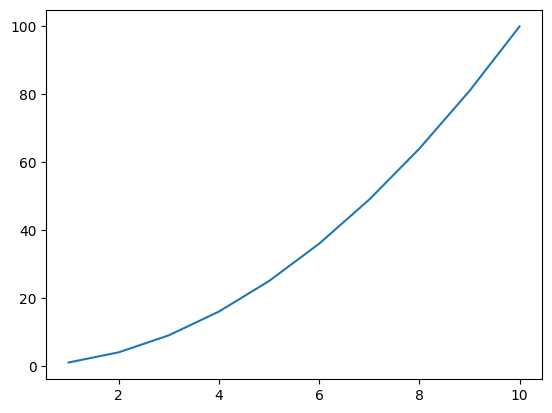

In [4]:
x = np.arange(1, 11)
y = x ** 2

plt.plot(x, y)          # draw the line
plt.show()              # display it

That works, but nobody looking at it knows what it shows. Add the labels.

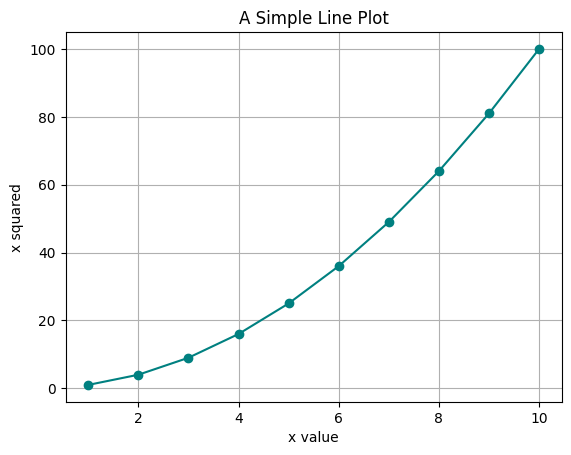

In [5]:
plt.plot(x, y, marker="o", color="teal")   # markers on each point, custom colour
plt.title("A Simple Line Plot")
plt.xlabel("x value")
plt.ylabel("x squared")
plt.grid(True)
plt.show()

The pattern is always the same: **plot → title → xlabel → ylabel → show.** Everything else is decoration. Remember these five and you can label any chart you make today.

---
## 2. Plotting straight from Pandas

You rarely start from raw x/y arrays. Pandas can plot a column directly with `.plot(kind=...)`, which is the fastest way to get a first look at real data.

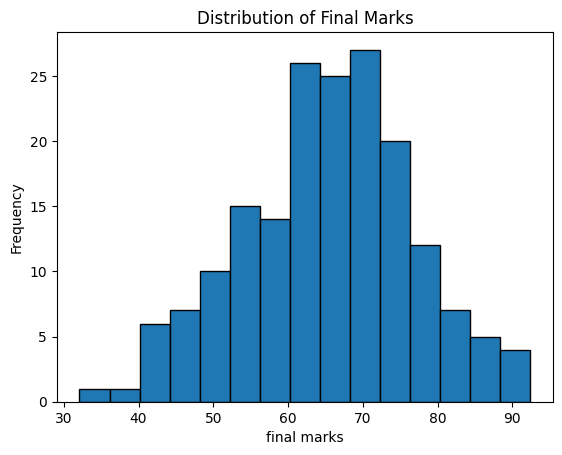

In [6]:
# A histogram: how are final marks distributed?
df["final_marks"].plot(kind="hist", bins=15, edgecolor="black", title="Distribution of Final Marks")
plt.xlabel("final marks")
plt.show()

### Reading a histogram *is* reading a distribution

A histogram groups values into bins and shows how many fall in each. The tall middle and thinner sides are the shape of the data. Let's make the statistics from last week **visible** by drawing the mean and median on top.

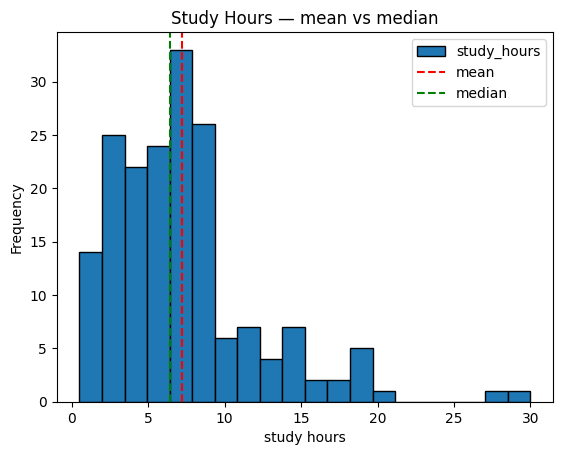

In [7]:
ax = df["study_hours"].plot(kind="hist", bins=20, edgecolor="black",
                            title="Study Hours — mean vs median")
plt.axvline(df["study_hours"].mean(),   color="red",   linestyle="--", label="mean")
plt.axvline(df["study_hours"].median(), color="green", linestyle="--", label="median")
plt.xlabel("study hours")
plt.legend()
plt.show()

Look at where the two lines fall. The **mean sits to the right of the median** — dragged there by the handful of students who study very long hours. This is the *right-skew* we measured as a number last week (`skew` ≈ 1.5), now something you can simply see. This single picture is why we fill missing values with the median, not the mean.

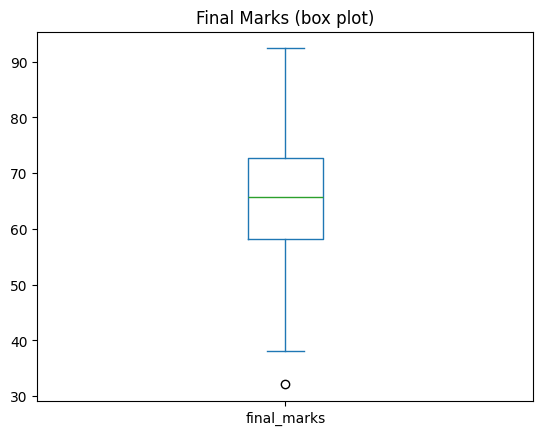

In [8]:
# The Pandas shortcut covers the common chart types
df["final_marks"].plot(kind="box", title="Final Marks (box plot)")
plt.show()

---
## 3. Seaborn — nicer plots that speak Pandas

**Seaborn** is built on top of Matplotlib. It has prettier defaults and understands DataFrames directly, so you pass a column name and it does the rest. For exploring data, it is usually the faster choice.

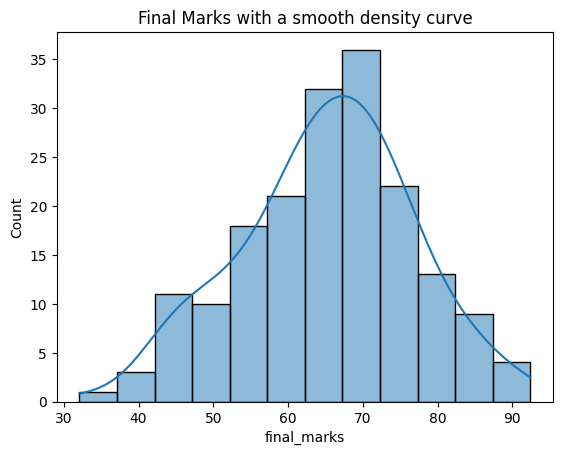

In [9]:
sns.histplot(data=df, x="final_marks", kde=True)
plt.title("Final Marks with a smooth density curve")
plt.show()

The smooth line (the **KDE**, kernel density estimate) is an idealized version of the histogram — the same shape, without the jagged bins. It makes the overall form of the distribution easy to see.

### The boxplot *is* the five-number summary

Last week we computed the minimum, Q1, median, Q3 and maximum. A boxplot draws exactly those:
- the **box** spans Q1 to Q3 (the interquartile range — the middle half of the data),
- the **line inside the box** is the median,
- the **whiskers** reach out to the typical range,
- the **dots** beyond them are outliers.

Every part of this picture is a statistic you already know.

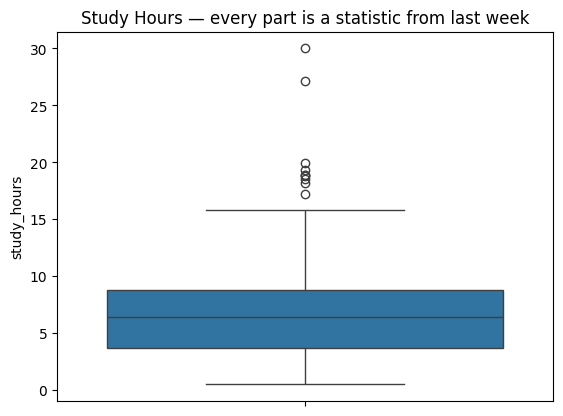

In [10]:
sns.boxplot(data=df, y="study_hours")
plt.title("Study Hours — every part is a statistic from last week")
plt.show()

The dots floating above are the long-study outliers — the same values that pulled the mean rightward in the histogram. Two different plots, telling the same story about the same students.

### Categorical plots — comparing groups

When one axis is a category (program, city, gender), these plots compare the groups.
- **`countplot`** — how many rows in each category (a bar chart of frequencies).
- **`barplot`** — a statistic (the mean by default) of a numeric column per category.
- **`violinplot`** — like a boxplot, but also shows the shape of each group's distribution.

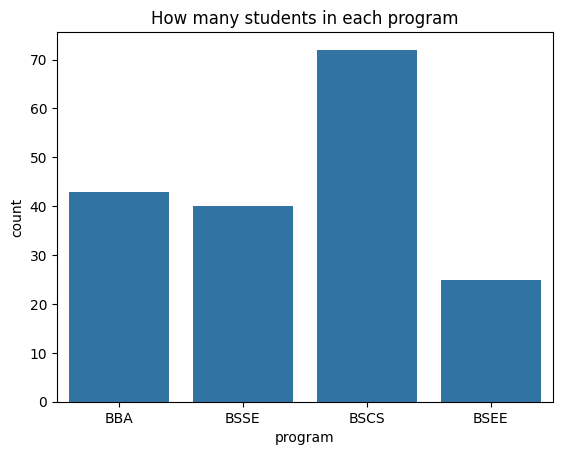

In [11]:
sns.countplot(data=df, x="program")
plt.title("How many students in each program")
plt.show()

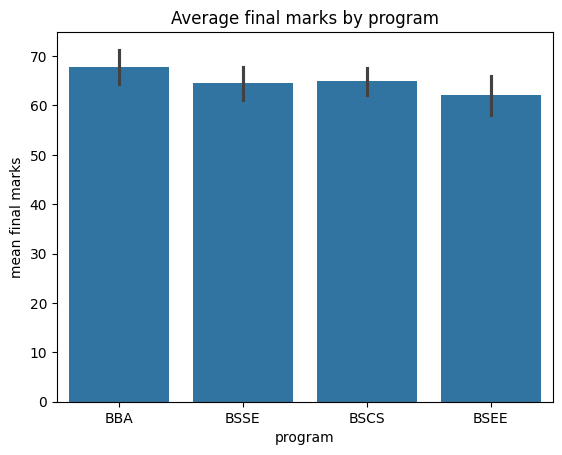

In [12]:
sns.barplot(data=df, x="program", y="final_marks")
plt.title("Average final marks by program")
plt.ylabel("mean final marks")
plt.show()

**A note on the little error bars.** The thin line on top of each bar shows *uncertainty* — how much the average might wobble. A short bar means a dependable average; a tall one means the group varies a lot or is small. We'll use this idea properly when we evaluate models later in the course.

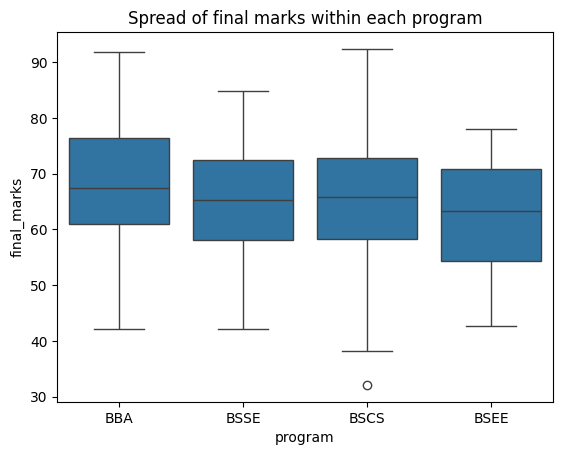

In [13]:
sns.boxplot(data=df, x="program", y="final_marks")
plt.title("Spread of final marks within each program")
plt.show()

---
## 4. Relationships between two variables

The most useful plots in machine learning show how **two** variables move together — because prediction is all about relationships.

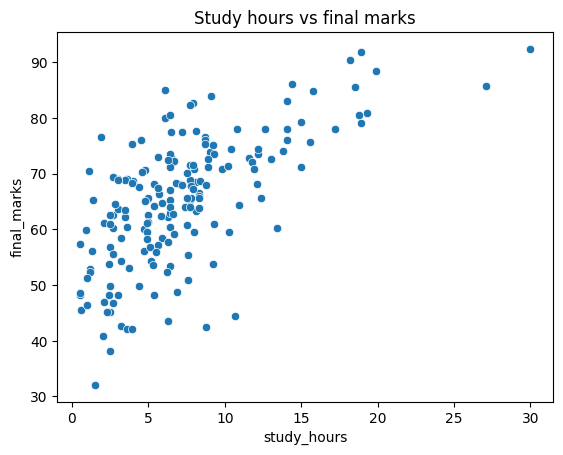

In [14]:
sns.scatterplot(data=df, x="study_hours", y="final_marks")
plt.title("Study hours vs final marks")
plt.show()

### This is what a correlation *looks like*

Last week we measured the correlation between study hours and final marks as **r ≈ 0.66** — a strong positive number. Now you can see what that number means: as study hours increase (moving right), marks tend to increase (moving up). The upward-drifting cloud of points **is** a correlation of 0.66.

A correlation near 0 would look like a shapeless blob; a correlation near 1 would look like a tight straight line. The scatter plot turns the abstract number into something you can point at.

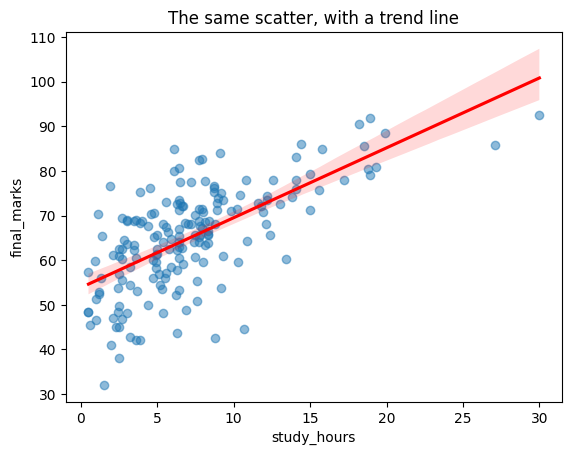

In [15]:
# Add a trend line straight through the cloud
sns.regplot(data=df, x="study_hours", y="final_marks",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title("The same scatter, with a trend line")
plt.show()

Keep that red line in mind. Later this week we build a model, and **that line is exactly what the model learns** — the single straight line that best fits the points.

### `pairplot` — every relationship at once

`pairplot` draws a scatter for *every pair* of numeric columns, with each column's own distribution down the diagonal. It's the fastest way to survey a whole dataset.

This one picture contains the three terms from the original syllabus:
- each diagonal chart is **univariate** (one variable),
- each off-diagonal scatter is **bivariate** (two variables),
- the whole grid together is **multivariate** (many variables at once).

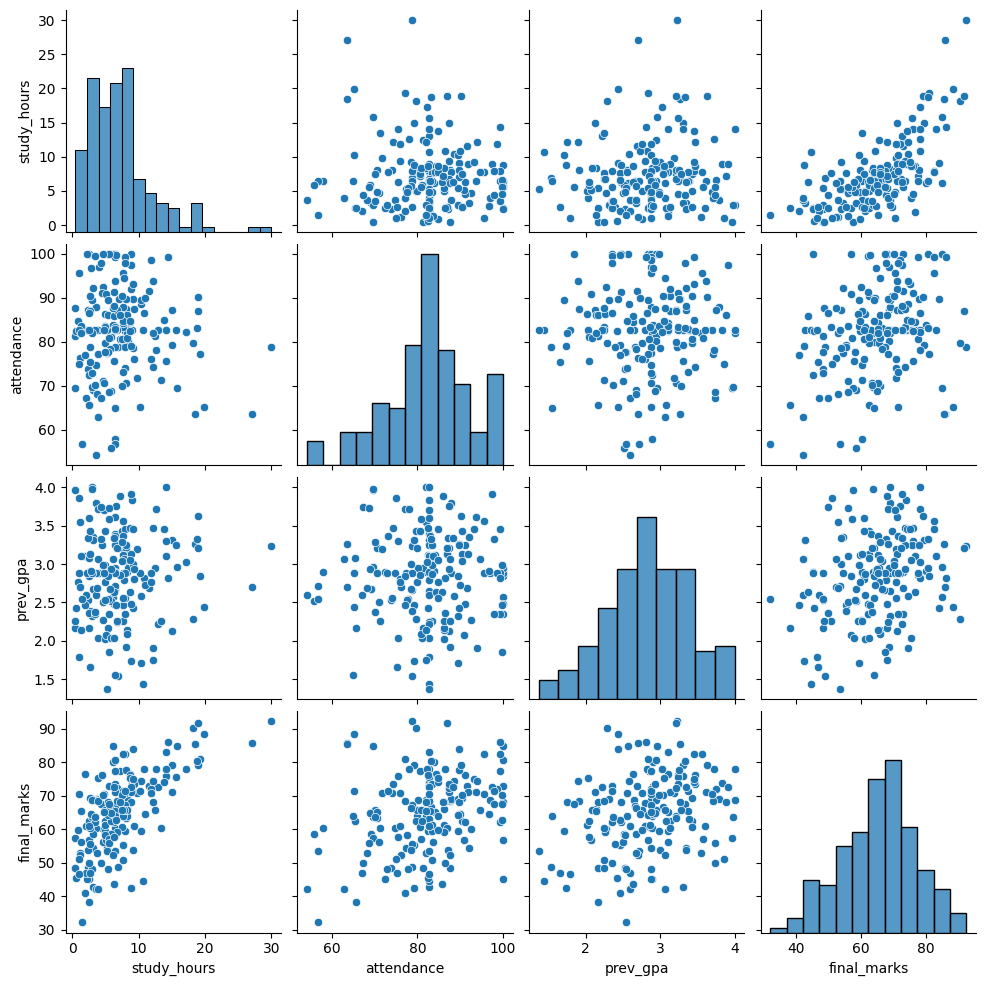

In [16]:
sns.pairplot(df[["study_hours", "attendance", "prev_gpa", "final_marks"]])
plt.show()

---
## 5. The heatmap — a whole dataset at a glance

Last week's correlation *matrix* was a grid of numbers. A **heatmap** colours that grid so the strong relationships jump out and the weak ones fade — the entire dataset's relationships, readable in one look.

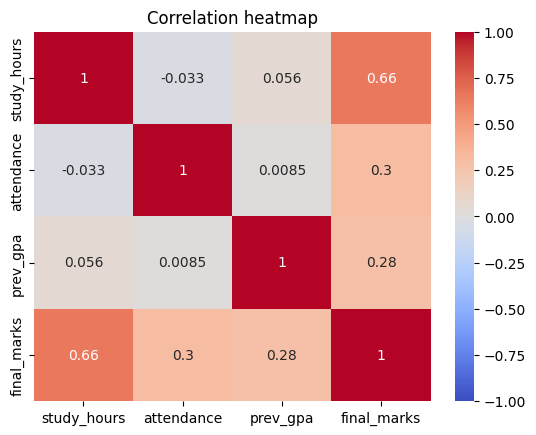

In [17]:
corr = df[["study_hours", "attendance", "prev_gpa", "final_marks"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.show()

How to read it: the diagonal is always deep red (every column correlates perfectly with itself, 1.0). Off the diagonal, **warmer = stronger positive**, cooler = weaker. The `study_hours`–`final_marks` cell glows warmest, confirming what the scatter plot showed. One glance now replaces reading a table of numbers cell by cell.

### Skewness, now that you can see it

Skewness is a single number that measures a distribution's lopsidedness. A positive value means a tail stretching to the right — exactly what we saw in the study-hours histogram.

study_hours skew: 1.54


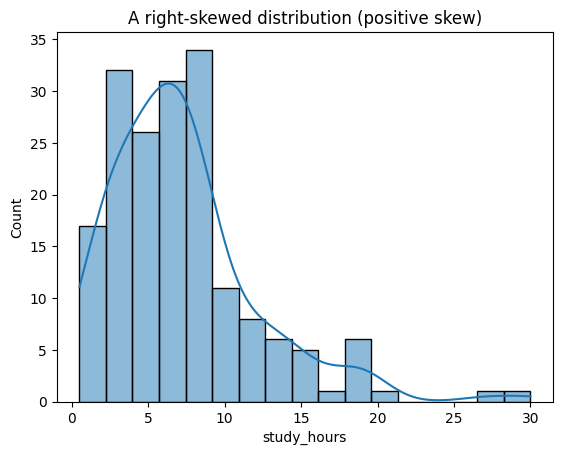

In [18]:
print("study_hours skew:", round(df["study_hours"].skew(), 2))   # positive → right tail

sns.histplot(data=df, x="study_hours", kde=True)
plt.title("A right-skewed distribution (positive skew)")
plt.show()

The positive number and the rightward tail are the same fact told two ways. (*Kurtosis* is a related measure of how heavy a distribution's tails are — worth knowing the word exists, but the histogram already tells you what you need.)

---
## Putting it together — three questions, three plots

Good data analysis is asking a question and answering it with the *right* picture. Three questions about our students, each answered by a single chart.

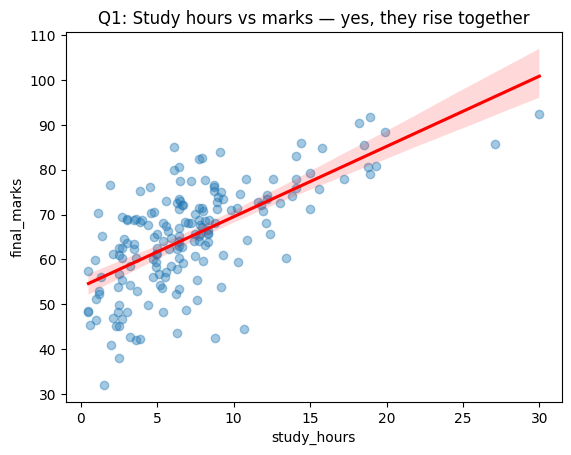

In [19]:
# Q1: Does studying relate to marks?  → a scatter plot
sns.regplot(data=df, x="study_hours", y="final_marks",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Q1: Study hours vs marks — yes, they rise together")
plt.show()

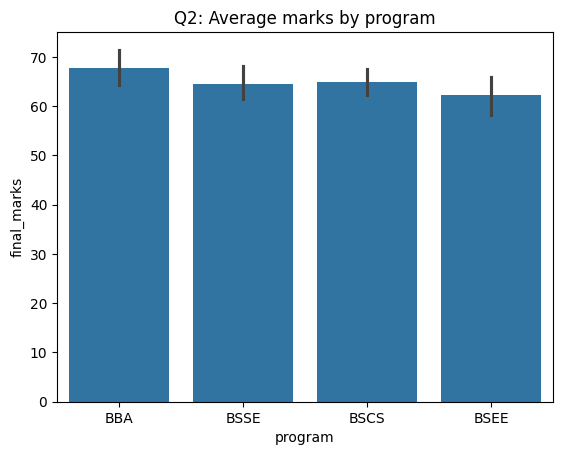

In [20]:
# Q2: Which program scores highest on average?  → a bar plot
sns.barplot(data=df, x="program", y="final_marks")
plt.title("Q2: Average marks by program")
plt.show()

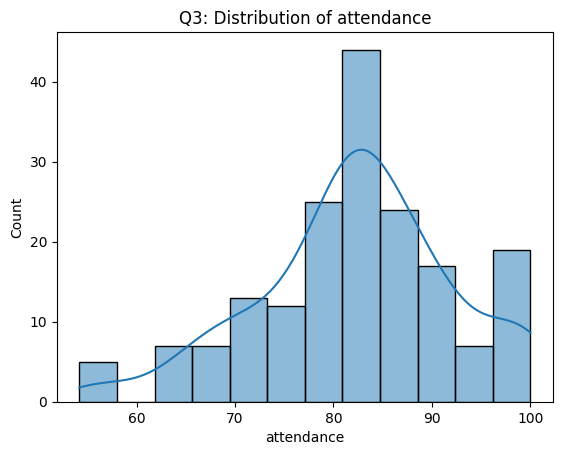

In [21]:
# Q3: Is attendance skewed?  → a histogram
sns.histplot(data=df, x="attendance", kde=True)
plt.title("Q3: Distribution of attendance")
plt.show()

---
## Summary

- Every Matplotlib chart follows **plot → title → xlabel → ylabel → show**; always label your axes.
- `df["col"].plot(kind=...)` plots a column straight from Pandas — `hist`, `box`, `line`, `bar`, `scatter`.
- A **histogram** shows a distribution; drawing the mean and median on it makes skew visible.
- **Seaborn** (`histplot`, `boxplot`, `countplot`, `barplot`, `violinplot`) gives nicer plots and reads DataFrames directly.
- A **boxplot** is the five-number summary drawn: box = IQR, line = median, dots = outliers.
- A **scatter plot** shows what a correlation looks like; `regplot` adds the trend line a model will later learn.
- **`pairplot`** surveys every pair of variables at once (univariate on the diagonal, bivariate off it).
- A **heatmap** turns the correlation matrix into a picture — strong relationships glow, weak ones fade.

Tomorrow you'll use all of these together in a full exploratory analysis, start to finish, on your own.